
# Step 1 : Import Libraries




In [14]:
# Uncomment บรรทัดด้านล่างถ้ายังไม่ได้ติดตั้ง
# !pip install pandas numpy scikit-learn matplotlib seaborn xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — ML models & metrics
from sklearn.ensemble        import RandomForestRegressor
from sklearn.linear_model    import Ridge
from sklearn.svm             import SVR
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, r2_score
from matplotlib.patches      import Patch

# XGBoost
from xgboost import XGBRegressor

# ── Style ─────────────────────────────────────────────────────
plt.style.use('dark_background')
COLORS = {
    'AAPL': '#76b900',
    'MSFT': '#ff9900',
    'AMZN': '#4285f4',
    'JPM' : '#aaaaaa',
    'GS'  : '#00bcf2', # Changed 'KO' to 'GS'
}
TICKERS = ['AAPL', 'MSFT', 'AMZN', 'JPM', 'GS'] # Changed 'KO' to 'GS'

print("✅ Import สำเร็จทุก library!")

✅ Import สำเร็จทุก library!


# Step 2 : Load Dataset

In [2]:
df = pd.read_csv('/content/StockPriceDataset_2022_2026.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f"📊 Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"📋 Columns    : {list(df.columns)}")
df.head(3)

📊 Shape      : 10,000 rows × 8 columns
📅 Date range : 2018-05-09  →  2026-03-20
📋 Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Ticker']


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker
0,2018-05-09,46.637501,46.849998,46.305000,46.840000,44.356316,92844800,AAPL
1,2018-05-09,237.979996,242.050003,237.250000,241.729996,210.825653,2434000,GS
2,2018-05-09,96.010002,96.970001,95.050003,96.940002,90.581367,27327400,MSFT


# Step 3 : Exploratory Data Analysis (EDA)





Missing values per column:
✅ ไม่มี missing values!

สถิติพื้นฐานของราคาปิดแต่ละหุ้น:
         count    mean     std     min     25%     50%     75%     max
Ticker                                                                
AAPL    2000.0  144.67   63.89   35.55   79.66  149.92  195.16  254.91
AMZN    2000.0  139.47   38.36   67.20   97.61  151.06  169.54  209.29
GS      2000.0  333.46  106.31  134.97  226.86  335.60  407.74  559.30
JPM     2000.0  148.79   39.53   79.03  114.39  140.81  178.89  236.28
MSFT    2000.0  269.04  100.70   94.13  183.10  276.43  377.39  405.34


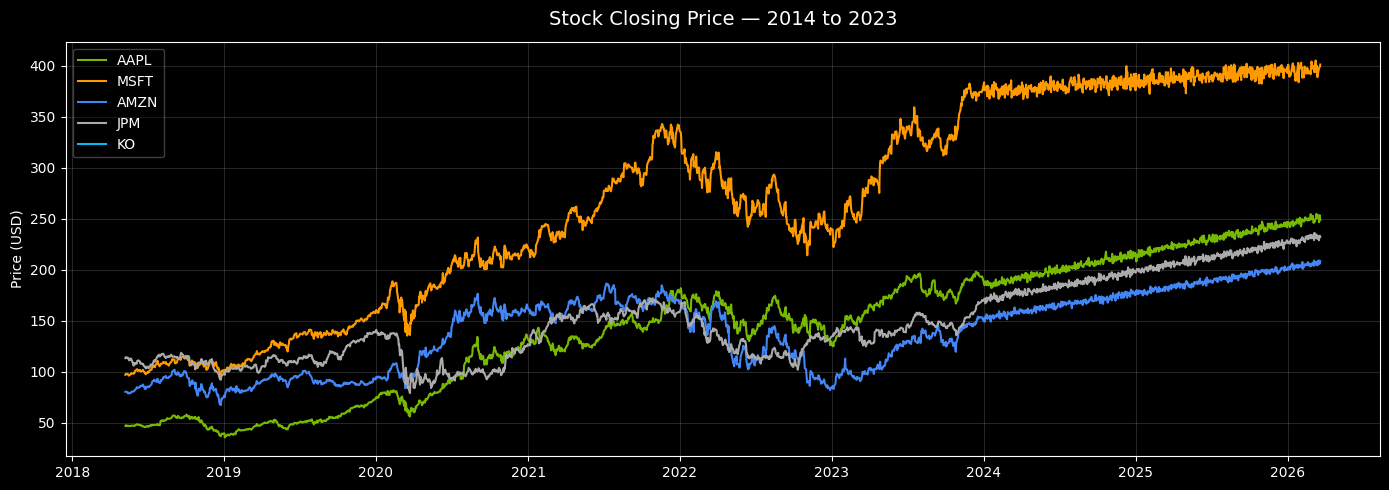

In [3]:
# ── ตรวจสอบ Missing Values ───────────────────────────────────
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "✅ ไม่มี missing values!")

# ── สถิติพื้นฐาน ──────────────────────────────────────────────
close_stats = df.groupby('Ticker')['Close'].describe().round(2)
print("\nสถิติพื้นฐานของราคาปิดแต่ละหุ้น:")
print(close_stats)

# ── Plot: ราคาหุ้นทุกตัว ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
for ticker in TICKERS:
    ticker_df = df[df['Ticker'] == ticker]
    ax.plot(ticker_df['Date'], ticker_df['Close'],
            label=ticker, color=COLORS[ticker], linewidth=1.5)
ax.set_title('Stock Closing Price — 2014 to 2023', fontsize=14, pad=12)
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', framealpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


# Step 4 : Feature Engineering

MSFT — หลัง feature engineering: 1,950 rows
Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'Returns', 'Price_Range', 'MA5', 'MA20', 'MA50', 'Volatility', 'RSI', 'Volume_MA', 'Volume_Ratio']


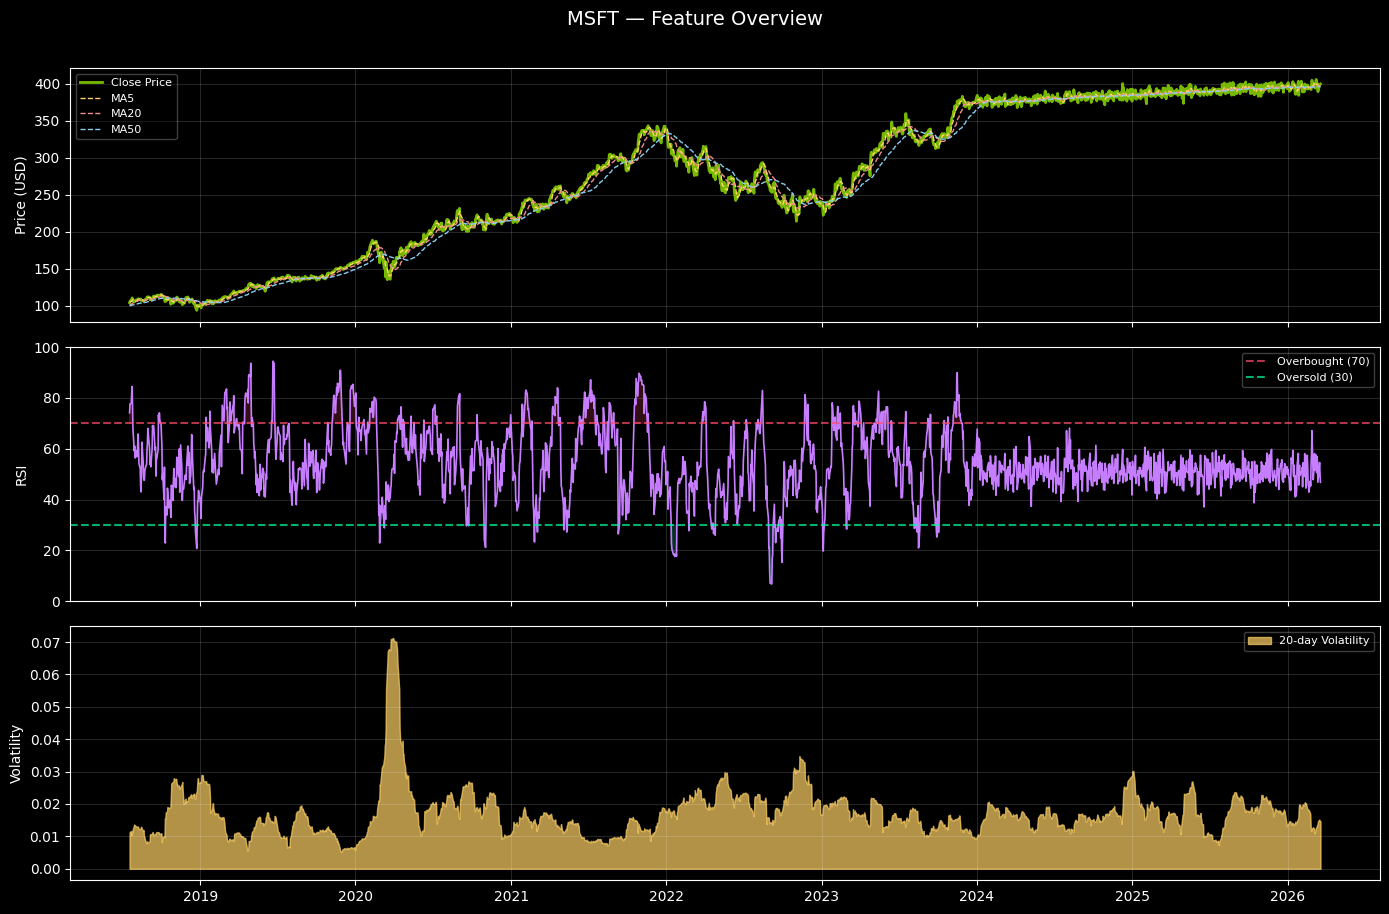

In [4]:
def create_features(df, ticker):
    """
    สร้าง feature matrix สำหรับหุ้น 1 ตัว

    Parameters
    ----------
    df     : DataFrame ในรูปแบบ long format
    ticker : ชื่อหุ้น เช่น 'MSFT'

    Returns
    -------
    DataFrame พร้อม features และ target column
    """
    ticker_data = df[df['Ticker'] == ticker].copy()
    data = ticker_data[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']].copy()

    # ── Features พื้นฐาน ────────────────────────────────────────
    data['Returns']     = data['Close'].pct_change()
    data['Price_Range'] = data['High'] - data['Low']

    # ── Moving Averages ──────────────────────────────────────────
    # MA ต่างช่วงเวลาให้มุมมองแนวโน้มระยะสั้น กลาง และยาว
    data['MA5']  = data['Close'].rolling(5).mean()
    data['MA20'] = data['Close'].rolling(20).mean()
    data['MA50'] = data['Close'].rolling(50).mean()

    # ── Volatility (20-day rolling std of returns) ───────────────
    data['Volatility'] = data['Returns'].rolling(20).std()

    # ── RSI — Relative Strength Index (14-day) ───────────────────
    # RSI > 70 = Overbought, RSI < 30 = Oversold
    gain     = data['Returns'].clip(lower=0)
    loss     = (-data['Returns']).clip(lower=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs       = avg_gain / (avg_loss + 1e-10)
    data['RSI'] = 100 - (100 / (1 + rs))

    # ── Volume Ratio ─────────────────────────────────────────────
    # Volume Ratio > 1 = ซื้อขายมากกว่าค่าเฉลี่ย → สัญญาณความสนใจของตลาด
    data['Volume_MA']    = data['Volume'].rolling(20).mean()
    data['Volume_Ratio'] = data['Volume'] / (data['Volume_MA'] + 1e-10)

    # ── Target: ราคาปิดวันถัดไป ──────────────────────────────────
    data['Target_Price'] = data['Close'].shift(-1)

    return data.dropna().reset_index(drop=True)


FEATURE_COLS = [
    'Close', 'Open', 'High', 'Low', 'Volume',
    'Returns', 'MA5', 'MA20', 'MA50',
    'Volatility', 'RSI', 'Price_Range', 'Volume_Ratio'
]

# ── ทดสอบกับ MSFT ────────────────────────────────────────────
sample = create_features(df, 'MSFT')
print(f"MSFT — หลัง feature engineering: {len(sample):,} rows")
print(f"Features: {[c for c in sample.columns if c not in ['Date','Target_Price']]}")
sample[['Date', 'Close', 'MA5', 'MA20', 'RSI', 'Volatility', 'Target_Price']].head(5)

# ── Visualize Features บน MSFT ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('MSFT — Feature Overview', fontsize=14, y=1.01)

ax = axes[0]
ax.plot(sample['Date'], sample['Close'], color='#76b900', lw=2,  label='Close Price')
ax.plot(sample['Date'], sample['MA5'],   color='#ffd166', lw=1,  ls='--', label='MA5')
ax.plot(sample['Date'], sample['MA20'],  color='#ef8c8c', lw=1,  ls='--', label='MA20')
ax.plot(sample['Date'], sample['MA50'],  color='#88ccee', lw=1,  ls='--', label='MA50')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=8, framealpha=0.3)
ax.grid(alpha=0.15)

ax = axes[1]
ax.plot(sample['Date'], sample['RSI'], color='#c77dff', lw=1.2)
ax.axhline(70, color='#ff4d6a', ls='--', alpha=0.7, label='Overbought (70)')
ax.axhline(30, color='#00ff9d', ls='--', alpha=0.7, label='Oversold (30)')
ax.fill_between(sample['Date'], sample['RSI'], 70,
                where=(sample['RSI'] >= 70), alpha=0.2, color='#ff4d6a')
ax.fill_between(sample['Date'], sample['RSI'], 30,
                where=(sample['RSI'] <= 30), alpha=0.2, color='#00ff9d')
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.15)

ax = axes[2]
ax.fill_between(sample['Date'], sample['Volatility'],
                alpha=0.7, color='#ffd166', label='20-day Volatility')
ax.set_ylabel('Volatility')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

# Step 5 : Feature Correlation Heatmap

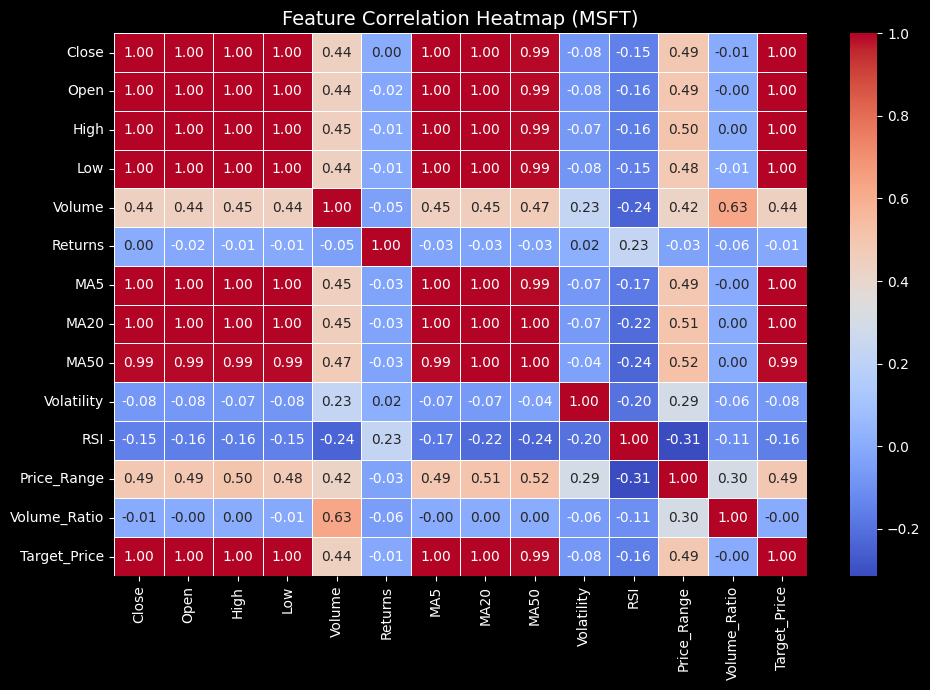

In [5]:
plt.figure(figsize=(10, 7))
corr = sample[FEATURE_COLS + ['Target_Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (MSFT)", fontsize=14)
plt.tight_layout()
plt.show()

# Step 6 : Pipeline + Train/Test Split

In [6]:
# ใช้ sklearn Pipeline รวม StandardScaler + Model ไว้ด้วยกัน
# ข้อดี:
#   1. ป้องกัน Data Leakage — Scaler fit เฉพาะ train fold เสมอ
#   2. Deploy ง่าย — บันทึก pipeline เดียวใช้ได้เลย
#   3. ทำ Cross-validation ได้ถูกต้องโดยอัตโนมัติ

def make_pipelines():
    """สร้าง dict ของ Pipeline ทั้ง 4 โมเดล"""
    return {
        'Ridge': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  Ridge(alpha=1.0))
            # Ridge ใช้ L2 Regularization จัดการ multicollinearity
            # ระหว่าง MA5/MA20/MA50 ที่ Correlation สูงมาก
        ]),
        'SVR': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  SVR(kernel='rbf', C=10, epsilon=0.1))
            # SVR ต้องการ scaling เสมอ — ไม่ scale จะ train ช้าและผลแย่
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
            # RF ไม่ต้องการ scaling แต่ใส่ใน pipeline เพื่อความสม่ำเสมอ
        ]),
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  XGBRegressor(n_estimators=100, learning_rate=0.1,
                                    max_depth=5, random_state=42,
                                    verbosity=0, n_jobs=-1))
        ]),
    }

PIPELINES = make_pipelines()

# ── Time-based Split ─────────────────────────────────────────
# ใช้ 80% แรกเป็น train, 20% หลังเป็น test
# ไม่สุ่ม เพราะข้อมูลหุ้นมีลำดับเวลา
msft_data = create_features(df, 'MSFT')
X_msft    = msft_data[FEATURE_COLS]
y_msft    = msft_data['Target_Price']
n         = len(msft_data)
idx       = int(n * 0.8)

X_tr_raw  = X_msft.iloc[:idx];   y_tr = y_msft.iloc[:idx]
X_te_raw  = X_msft.iloc[idx:];   y_te = y_msft.iloc[idx:]
dates_te  = msft_data['Date'].iloc[idx:].reset_index(drop=True)

print(f"  📅 Train: {len(X_tr_raw):,} rows  ({msft_data['Date'].iloc[0].date()} → {msft_data['Date'].iloc[idx-1].date()})")
print(f"  📅 Test : {len(X_te_raw):,} rows  ({msft_data['Date'].iloc[idx].date()} → {msft_data['Date'].iloc[-1].date()})")

  📅 Train: 1,560 rows  (2018-07-19 → 2024-09-19)
  📅 Test : 390 rows  (2024-09-20 → 2026-03-19)


# Step 7 : Cross-Validation (TimeSeriesSplit)

📊 Cross-Validation Results (MSFT) — TimeSeriesSplit, 5 folds
  Ridge            RMSE/fold: [5.33 5.   5.39 5.98 6.11]  → mean=5.56 ± 0.42
  SVR              RMSE/fold: [ 78.49 106.71  14.76  90.62  17.6 ]  → mean=61.64 ± 38.19
  Random Forest    RMSE/fold: [55.86 52.11  6.24 31.99 10.77]  → mean=31.40 ± 20.43
  XGBoost          RMSE/fold: [56.9  53.17  5.9  38.59 10.92]  → mean=33.10 ± 21.12
💡 mean RMSE ต่ำ + std ต่ำ = โมเดลสม่ำเสมอข้ามช่วงเวลา


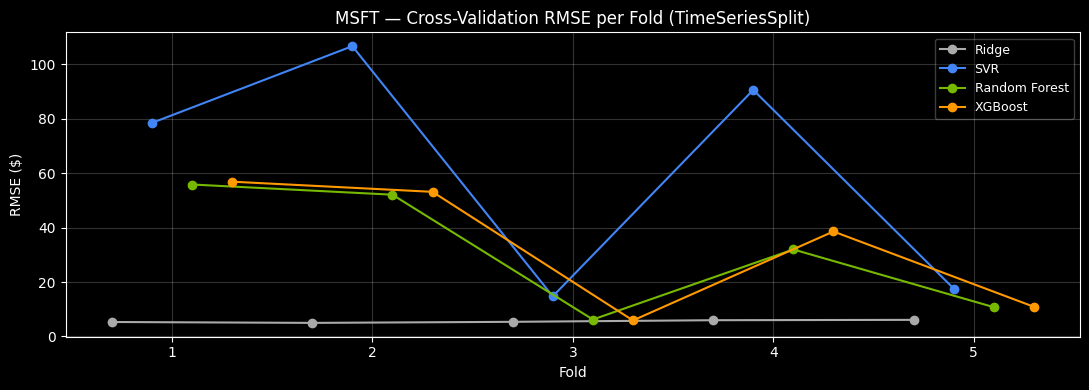

In [8]:
# ใช้ TimeSeriesSplit แทน KFold ธรรมดา
# เพราะข้อมูลหุ้นมีลำดับเวลา — ห้าม shuffle หรือใช้อนาคตทำนายอดีต
#
#  Fold 1 : [===Train===][Test]
#  Fold 2 : [=====Train=====][Test]
#  Fold 3 : [=======Train=======][Test]
#  ...always train on past, test on future

tscv = TimeSeriesSplit(n_splits=5)

print("=" * 65)
print("📊 Cross-Validation Results (MSFT) — TimeSeriesSplit, 5 folds")
print("=" * 65)

cv_results = {}
for name, pipe in PIPELINES.items():
    scores      = cross_val_score(pipe, X_msft, y_msft, cv=tscv,
                                  scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = np.abs(scores)
    cv_results[name] = rmse_scores
    print(f"  {name:15s}  RMSE/fold: {np.round(rmse_scores,2)}  "
          f"→ mean={rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")

print("=" * 65)
print("💡 mean RMSE ต่ำ + std ต่ำ = โมเดลสม่ำเสมอข้ามช่วงเวลา")

# ── Visualize CV scores ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
x      = np.arange(1, 6)
offset = np.linspace(-0.3, 0.3, 4)
cv_colors = ['#aaaaaa', '#4285f4', '#76b900', '#ff9900']

for (name, scores), dx, c in zip(cv_results.items(), offset, cv_colors):
    ax.plot(x + dx, scores, 'o-', color=c, lw=1.5, ms=6, label=name)

ax.set_xlabel('Fold')
ax.set_ylabel('RMSE ($)')
ax.set_title('MSFT — Cross-Validation RMSE per Fold (TimeSeriesSplit)', fontsize=12)
ax.set_xticks(x)
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Step 8 : Hyperparameter Tuning (RandomizedSearchCV)

In [9]:
# Tune RF และ XGBoost ซึ่งมี hyperparameter มากที่สุด
# ใช้ RandomizedSearchCV แทน GridSearchCV เพราะ:
#   - ลอง n_iter combinations แบบสุ่ม → เร็วกว่ามาก
#   - งานวิจัยพบว่าให้ผลใกล้เคียง GridSearch ในเวลาน้อยกว่าหลายเท่า

rf_param_grid = {
    'model__n_estimators'     : [100, 200, 300],
    'model__max_depth'        : [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf' : [1, 2, 4],
    'model__max_features'     : ['sqrt', 'log2', 0.5],
}
xgb_param_grid = {
    'model__n_estimators'    : [100, 200, 300],
    'model__max_depth'       : [3, 5, 7],
    'model__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'model__subsample'       : [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
}

tuned_models = {}
for model_name, pipe, param_grid in [
    ('Random Forest', make_pipelines()['Random Forest'], rf_param_grid),
    ('XGBoost',       make_pipelines()['XGBoost'],       xgb_param_grid),
]:
    print(f"\n🔍 Tuning {model_name}...")
    search = RandomizedSearchCV(
        pipe, param_distributions=param_grid,
        n_iter=20, cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1, verbose=0
    )
    search.fit(X_msft, y_msft)
    print(f"  ✅ Best CV RMSE : ${-search.best_score_:.4f}")
    print(f"  🏆 Best params  : {search.best_params_}")
    tuned_models[model_name] = search.best_estimator_

print("\n✅ Tuning เสร็จสิ้น!")


🔍 Tuning Random Forest...
  ✅ Best CV RMSE : $31.3073
  🏆 Best params  : {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 10}

🔍 Tuning XGBoost...
  ✅ Best CV RMSE : $32.1820
  🏆 Best params  : {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

✅ Tuning เสร็จสิ้น!


# Step 9 : Model Evaluation — Default vs Tuned (MSFT)

📊 Final Evaluation — MSFT Test Set
  Ridge                 RMSE=$6.43  R²=-0.0070
  SVR                   RMSE=$21.08  R²=-9.8230
  Random Forest         RMSE=$10.61  R²=-1.7412
  XGBoost               RMSE=$10.62  R²=-1.7497
  ---
  Random Forest (Tuned)  RMSE=$10.11  R²=-1.4895  ← after tuning
  XGBoost (Tuned)       RMSE=$10.69  R²=-1.7852  ← after tuning


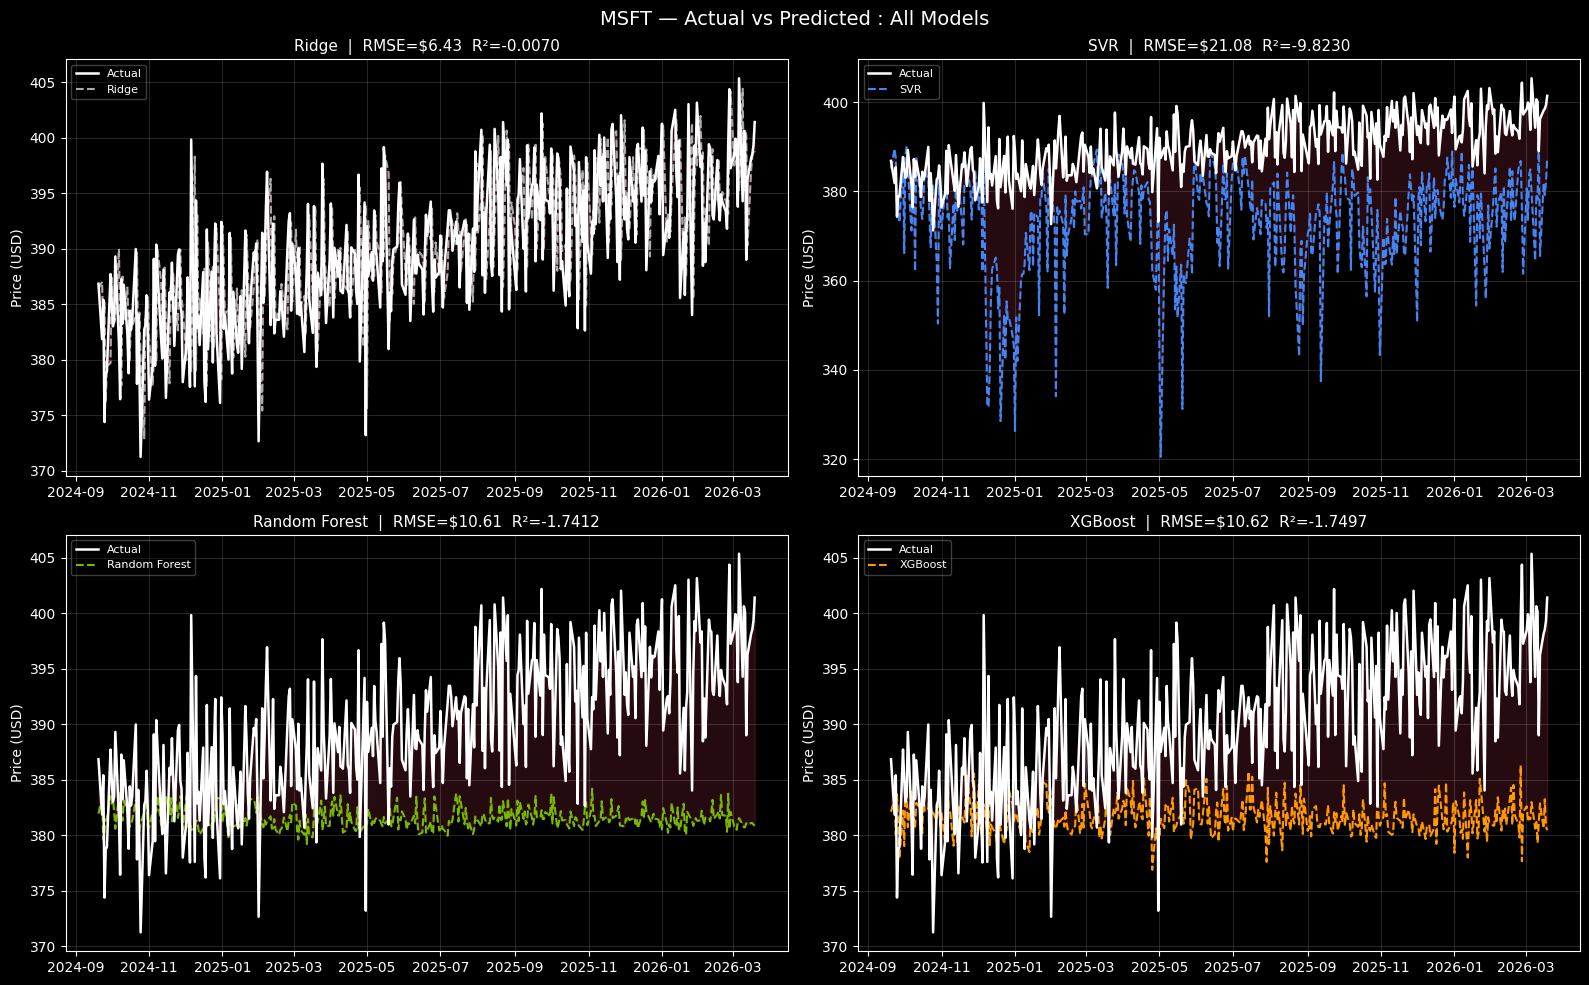

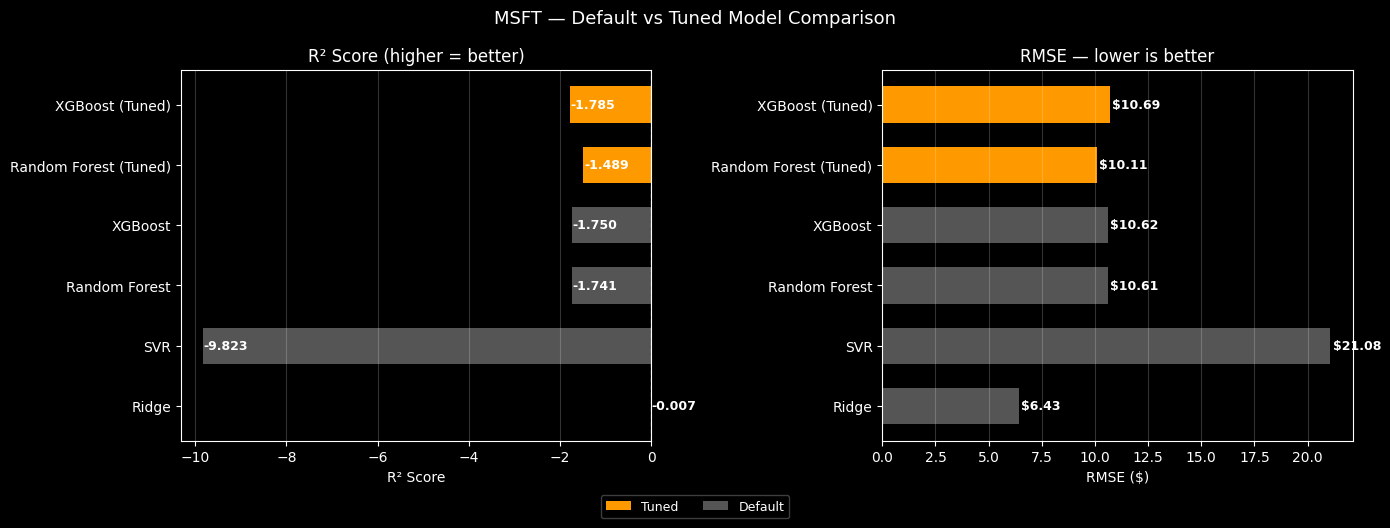

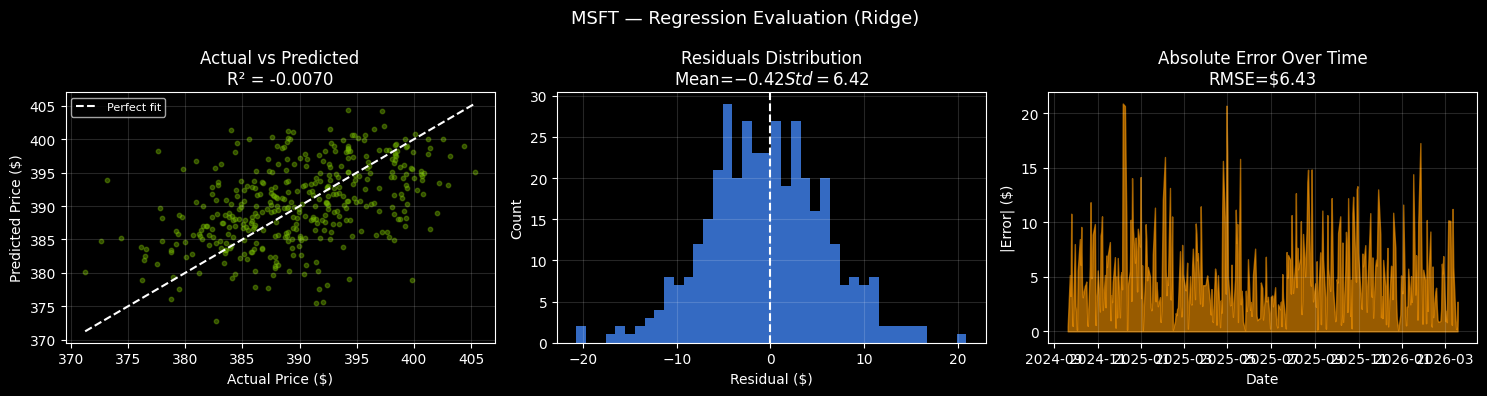

In [10]:
print("=" * 65)
print("📊 Final Evaluation — MSFT Test Set")
print("=" * 65)

final_results = {}

# Default pipelines
for name, pipe in PIPELINES.items():
    pipe.fit(X_tr_raw, y_tr)
    y_pred = pipe.predict(X_te_raw)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    r2     = r2_score(y_te, y_pred)
    final_results[name] = {'y_pred': y_pred, 'rmse': rmse, 'r2': r2, 'tuned': False}
    print(f"  {name:20s}  RMSE=${rmse:.2f}  R²={r2:.4f}")

print("  ---")
# Tuned pipelines
for name, pipe in tuned_models.items():
    pipe.fit(X_tr_raw, y_tr)
    y_pred = pipe.predict(X_te_raw)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    r2     = r2_score(y_te, y_pred)
    final_results[f'{name} (Tuned)'] = {'y_pred': y_pred, 'rmse': rmse, 'r2': r2, 'tuned': True}
    print(f"  {name+' (Tuned)':20s}  RMSE=${rmse:.2f}  R²={r2:.4f}  ← after tuning")

print("=" * 65)

# ── Actual vs Predicted (ทุกโมเดล) ──────────────────────────
MODEL_COLORS = {
    'Ridge'         : '#aaaaaa',
    'SVR'           : '#4285f4',
    'Random Forest' : '#76b900',
    'XGBoost'       : '#ff9900',
}
actual = np.array(y_te)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MSFT — Actual vs Predicted : All Models', fontsize=14)
axes = axes.flatten()

for ax, (name, res) in zip(axes, {k: v for k, v in final_results.items() if '(Tuned)' not in k}.items()):
    c = MODEL_COLORS[name]
    ax.plot(dates_te, actual,        color='white', lw=1.8, label='Actual',  zorder=3)
    ax.plot(dates_te, res['y_pred'], color=c,       lw=1.5, label=name, ls='--', zorder=2)
    ax.fill_between(dates_te, actual, res['y_pred'], alpha=0.15, color='#ff4d6a')
    ax.set_title(f"{name}  |  RMSE=${res['rmse']:.2f}  R²={res['r2']:.4f}", fontsize=11)
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=8, framealpha=0.3)
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

# ── Default vs Tuned Bar Chart ────────────────────────────────
labels     = list(final_results.keys())
rmse_vals  = [final_results[k]['rmse'] for k in labels]
r2_vals    = [final_results[k]['r2']   for k in labels]
bar_colors = ['#ff9900' if final_results[k]['tuned'] else '#555555' for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MSFT — Default vs Tuned Model Comparison', fontsize=13)

ax = axes[0]
bars = ax.barh(labels, r2_vals, color=bar_colors, edgecolor='none', height=0.6)
ax.axvline(0, color='white', lw=1, ls='--', alpha=0.4)
ax.set_xlabel('R² Score')
ax.set_title('R² Score (higher = better)')
ax.grid(axis='x', alpha=0.2)
for bar, v in zip(bars, r2_vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

ax = axes[1]
bars = ax.barh(labels, rmse_vals, color=bar_colors, edgecolor='none', height=0.6)
ax.set_xlabel('RMSE ($)')
ax.set_title('RMSE — lower is better')
ax.grid(axis='x', alpha=0.2)
for bar, v in zip(bars, rmse_vals):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'${v:.2f}', va='center', fontsize=9, fontweight='bold')

legend_elements = [Patch(facecolor='#ff9900', label='Tuned'),
                   Patch(facecolor='#555555', label='Default')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           framealpha=0.3, fontsize=9, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# ── Residual Analysis (Best model) ───────────────────────────
best_default_name = min(
    {k: v for k, v in final_results.items() if '(Tuned)' not in k},
    key=lambda k: final_results[k]['rmse']
)
best_pred = final_results[best_default_name]['y_pred']
residuals = actual - best_pred
rmse_best = final_results[best_default_name]['rmse']
r2_best   = final_results[best_default_name]['r2']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'MSFT — Regression Evaluation ({best_default_name})', fontsize=13)

ax = axes[0]
ax.scatter(actual, best_pred, alpha=0.4, color='#76b900', s=10)
mn, mx = min(actual.min(), best_pred.min()), max(actual.max(), best_pred.max())
ax.plot([mn, mx], [mn, mx], color='white', lw=1.5, ls='--', label='Perfect fit')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.set_title(f'Actual vs Predicted\nR² = {r2_best:.4f}')
ax.legend(fontsize=8)
ax.grid(alpha=0.15)

ax = axes[1]
ax.hist(residuals, bins=40, color='#4285f4', edgecolor='none', alpha=0.8)
ax.axvline(0, color='white', lw=1.5, ls='--')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals Distribution\nMean=${residuals.mean():.2f}  Std=${residuals.std():.2f}')
ax.grid(alpha=0.15)

ax = axes[2]
ax.fill_between(dates_te, np.abs(residuals), alpha=0.6, color='#ff9900')
ax.set_xlabel('Date')
ax.set_ylabel('|Error| ($)')
ax.set_title(f'Absolute Error Over Time\nRMSE=${rmse_best:.2f}')
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

# Step 10 : Feature Importance (MSFT)

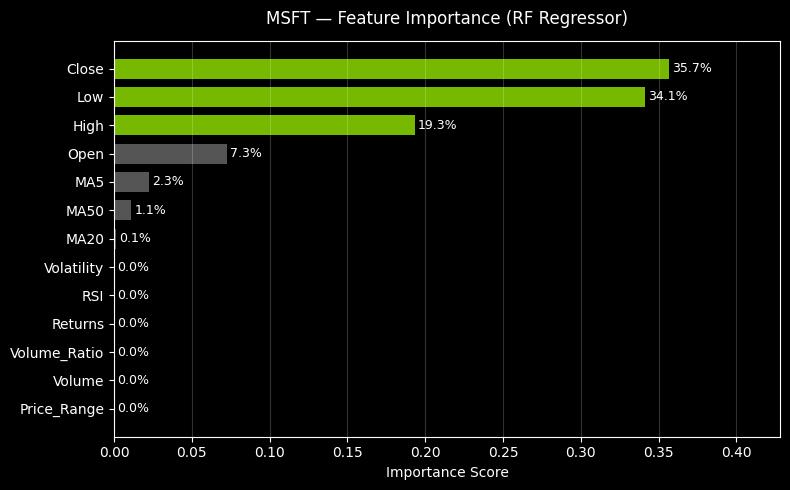


🏆 Top 3 Most Important Features:
  Close            35.7%
  Low              34.1%
  High             19.3%


In [11]:
# ใช้ RF model (default) เพื่อดู feature importance
rf_pipe = PIPELINES['Random Forest']
rf_pipe.fit(X_tr_raw, y_tr)
rf_model    = rf_pipe.named_steps['model']
importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = ['#76b900' if imp > 0.1 else '#555' for imp in feat_df['Importance']]
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color=colors_bar, edgecolor='none', height=0.7)
for bar, imp in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{imp*100:.1f}%', va='center', fontsize=9, color='white')
ax.set_title('MSFT — Feature Importance (RF Regressor)', fontsize=12, pad=12)
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

print("\n🏆 Top 3 Most Important Features:")
for i, row in feat_df.tail(3).iloc[::-1].iterrows():
    print(f"  {row['Feature']:15s}  {row['Importance']*100:.1f}%")

# Step 11 : Train Best Model × All Tickers

In [15]:
# เลือก tuned model ที่ดีที่สุดจาก Step 9 มาใช้กับทุกหุ้น
BEST_MODEL_NAME = min(
    tuned_models,
    key=lambda k: final_results[f'{k} (Tuned)']['rmse']
)
print(f"🏆 Best model: {BEST_MODEL_NAME} (Tuned)\n")

all_results = []

for ticker in TICKERS:
    data  = create_features(df, ticker)
    X_all = data[FEATURE_COLS]
    y_all = data['Target_Price']
    n_t   = len(data)
    idx_t = int(n_t * 0.8)

    X_tr_t = X_all.iloc[:idx_t];  y_tr_t = y_all.iloc[:idx_t]
    X_te_t = X_all.iloc[idx_t:];  y_te_t = y_all.iloc[idx_t:]

    best_pipe = tuned_models[BEST_MODEL_NAME]
    best_pipe.fit(X_tr_t, y_tr_t)
    y_pred = best_pipe.predict(X_te_t)
    rmse   = np.sqrt(mean_squared_error(y_te_t, y_pred))
    r2     = r2_score(y_te_t, y_pred)

    all_results.append({
        'Ticker'       : ticker,
        'Current Price': f"${data['Close'].iloc[-1]:.2f}",
        'RMSE ($)'     : round(rmse, 2),
        'R²'           : round(r2, 4),
    })
    print(f"  ✅ {ticker:5s} — RMSE=${rmse:.2f}  R²={r2:.4f}")

print("\n" + "=" * 55)
print("📊 SUMMARY — Best Tuned Model × All Tickers")
print("=" * 55)
summary_df = pd.DataFrame(all_results).set_index('Ticker')
print(summary_df)

🏆 Best model: Random Forest (Tuned)

  ✅ AAPL  — RMSE=$26.56  R²=-3.1336
  ✅ MSFT  — RMSE=$10.11  R²=-1.4895
  ✅ AMZN  — RMSE=$12.54  R²=-0.3417
  ✅ JPM   — RMSE=$24.97  R²=-3.0299
  ✅ GS    — RMSE=$71.80  R²=-3.3159

📊 SUMMARY — Best Tuned Model × All Tickers
       Current Price  RMSE ($)      R²
Ticker                                
AAPL         $253.60     26.56 -3.1336
MSFT         $399.31     10.11 -1.4895
AMZN         $206.36     12.54 -0.3417
JPM          $233.39     24.97 -3.0299
GS           $551.56     71.80 -3.3159


# Step 12 : Comparison Visualization — All Tickers

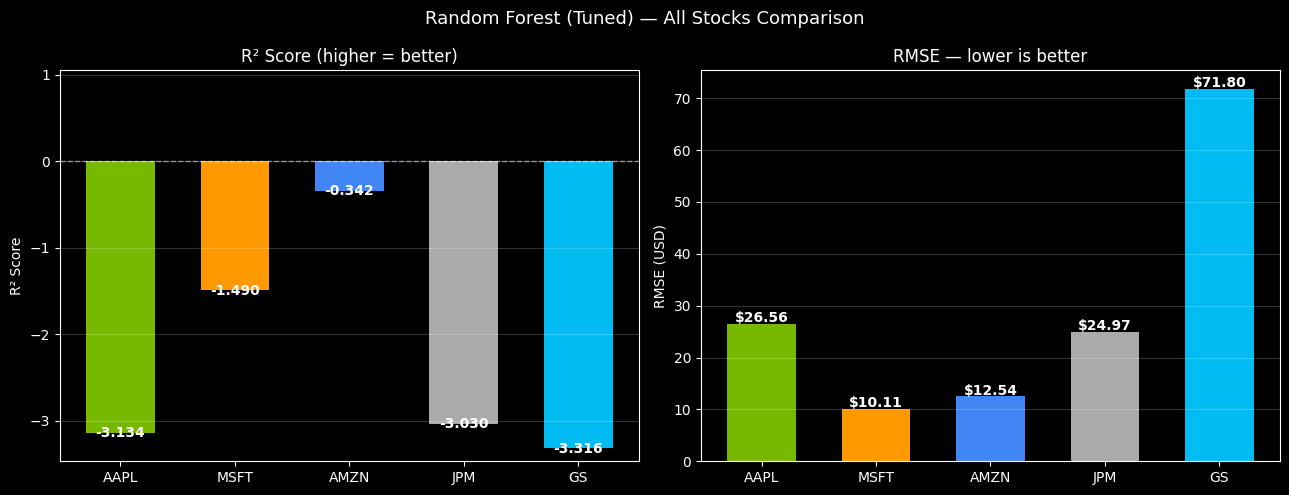

In [16]:
r2_vals_all   = [r['R²']       for r in all_results]
rmse_vals_all = [r['RMSE ($)'] for r in all_results]
tickers_all   = [r['Ticker']   for r in all_results]
colors_all    = [COLORS[t]     for t in tickers_all]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{BEST_MODEL_NAME} (Tuned) — All Stocks Comparison', fontsize=13)

ax = axes[0]
bars = ax.bar(tickers_all, r2_vals_all, color=colors_all, edgecolor='none', width=0.6)
ax.axhline(0, color='white', lw=1, ls='--', alpha=0.5)
ax.set_ylabel('R² Score')
ax.set_title('R² Score (higher = better)')
ax.set_ylim(min(min(r2_vals_all) - 0.15, -0.5), 1.05)
ax.grid(axis='y', alpha=0.2)
for bar, v in zip(bars, r2_vals_all):
    ypos = v + 0.02 if v >= 0 else v - 0.05
    ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{v:.3f}',
            ha='center', fontsize=10, fontweight='bold')

ax = axes[1]
bars = ax.bar(tickers_all, rmse_vals_all, color=colors_all, edgecolor='none', width=0.6)
ax.set_ylabel('RMSE (USD)')
ax.set_title('RMSE — lower is better')
ax.grid(axis='y', alpha=0.2)
for bar, v in zip(bars, rmse_vals_all):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f'${v:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Step 13 : Feature Importance Heatmap — All Tickers

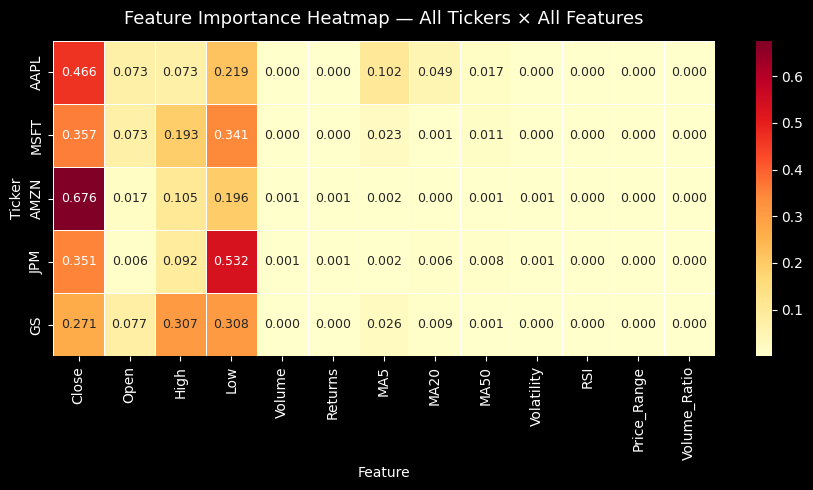


✅ Pipeline ครบทุกขั้นตอนแล้ว!


In [17]:
importance_matrix = {}

for ticker in TICKERS:
    data  = create_features(df, ticker)
    X_all = data[FEATURE_COLS]
    y_all = data['Target_Price']
    n_t   = len(data)
    idx_t = int(n_t * 0.8)

    pipe = make_pipelines()['Random Forest']
    pipe.fit(X_all.iloc[:idx_t], y_all.iloc[:idx_t])
    importance_matrix[ticker] = pipe.named_steps['model'].feature_importances_

imp_df = pd.DataFrame(importance_matrix, index=FEATURE_COLS)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    imp_df.T,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Feature Importance Heatmap — All Tickers × All Features', fontsize=13, pad=12)
ax.set_xlabel('Feature')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.show()

print("\n✅ Pipeline ครบทุกขั้นตอนแล้ว!")